## GloVe Embedding Vectors

Download GloVe from: https://nlp.stanford.edu/projects/glove/

Start with the smallest verson, `glove.6B`.

In [54]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_distances
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


Load GloVe embeddings

In [ ]:
filepath='/Users/andy/_data/glove.6B/glove.6B.300d.txt'
embeddings = {}

with open(filepath, 'r', encoding='utf-8') as file:
    for line in file:
        parts = line.split() # length is [0] word, [1:] embedding vector
        word = parts[0]
        vector = np.array(parts[1:], dtype=np.float32)
        embeddings[word] = vector

len(embeddings)

400000

Distance between words

In [ ]:
def word_distance(word1, word2, embeddings):
    if word1 not in embeddings.keys():
        print("Word 1 not in embedding vocabulary")
        return
    
    if word2 not in embeddings.keys():
        print("Word 2 not in embedding vocabulary")
        return

    distance = cosine_distances(
        embeddings[word1].reshape(1, -1),
        embeddings[word2].reshape(1, -1)
    )

    return distance[0][0]


In [44]:
word_distance('germany', 'germany', embeddings)

np.float32(1.1920929e-07)

Visualize distance between words 

In [122]:
word_list = ['king', 'queen', 'man', 'woman', 'prince', 'princess']

vectors = np.array([embeddings[word] for word in word_list])
print(f'{vectors.shape}')

pca = PCA(n_components=2)
reduced_vectors = pca.fit_transform(vectors)
print(f'{reduced_vectors.shape}')

(6, 300)
(6, 2)


In [124]:
v_queen = (embeddings['queen'] - embeddings['woman'] + embeddings['man']).reshape(1,-1)
v_king = (embeddings['king'] - embeddings['man'] + embeddings['woman']).reshape(1,-1)
print(v_queen.shape)

v_queen_2D = pca.transform(v_queen)
v_king_2D = pca.transform(v_king)
print(v_queen_2D.shape)

(1, 300)
(1, 2)


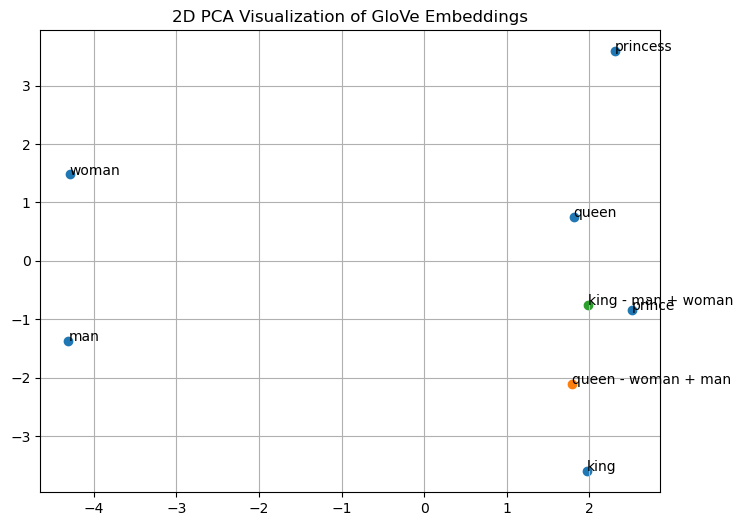

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(reduced_vectors[:, 0], reduced_vectors[:, 1])
plt.scatter(v_queen_2D[:,0], v_queen_2D[:,1])
plt.scatter(v_king_2D[:,0], v_king_2D[:,1])

for i, word in enumerate(word_list):
    plt.annotate(word, (reduced_vectors[i, 0], reduced_vectors[i, 1]))

plt.annotate('queen - woman + man', (v_queen_2D[:,0], v_queen_2D[:,1]))
plt.annotate('king - man + woman', (v_king_2D[:,0], v_king_2D[:,1]))

plt.title('2D PCA Visualization of GloVe Embeddings')
plt.grid(True)
plt.show()